# 05 - Naive RAG Pipeline (LangGraph + LangChain + PydanticAI)

Questo notebook costruisce e testa una **baseline Naive RAG** chiara e riusabile:
1. `normalize_query`
2. `retrieve_top_k` su indice Qdrant creato nel notebook 04
3. `build_context` con provenance
4. `generate_answer_structured` validato con schemi tipizzati

Il notebook include anche un **mini benchmark rapido** (MCQ + no-hint+judge) allineato allo stile metriche del notebook `evaluation/02`.


## 1) Setup ambiente, import e ruolo delle librerie

In questa sezione:
- risolviamo la root progetto e configuriamo `sys.path`
- carichiamo le variabili `.env`
- importiamo il runtime RAG e le utility benchmark condivise in `src`
- verifichiamo le versioni principali (`langgraph`, `langchain`, `pydantic`, `pydantic-ai`, `qdrant-client`)

Ruolo librerie:
- **LangGraph**: orchestrazione del flusso naive
- **LangChain**: integrazione LLM OpenAI-compatible
- **PydanticAI/Pydantic**: output strutturati e validazione robusta
- **Qdrant client**: retrieval vettoriale e payload filtering


In [1]:
from __future__ import annotations

import importlib.metadata as im
import json
import os
import sys
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def _find_repo_root_for_bootstrap(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'notebooks' / 'pipelines' / 'common' / 'bootstrap.py').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('Project root non trovato. Avvia il notebook dentro il repository.')


_BOOTSTRAP_ROOT = _find_repo_root_for_bootstrap(Path.cwd().resolve())
if str(_BOOTSTRAP_ROOT) not in sys.path:
    sys.path.insert(0, str(_BOOTSTRAP_ROOT))

from notebooks.pipelines.common.bootstrap import bootstrap_notebook

ROOT, SRC = bootstrap_notebook(start=Path.cwd().resolve())

from legal_indexing.rag_runtime import (
    JudgeResult,
    McqAnswer,
    NoHintAnswer,
    QdrantPayloadFieldMap,
    RagRuntimeConfig,
    align_record,
    build_comparison_table,
    build_dataset_summary,
    build_extended_summary,
    build_judge_prompt,
    build_mcq_prompt,
    build_no_hint_prompt,
    build_rag_graph,
    is_effective_answer,
    load_valid_rows,
    post_structured_chat,
    prepare_runtime,
    resolve_ollama_chat_url,
    run_rag_question,
    run_rag_retrieval_context,
    summarize_error_heads,
    validate_judge_output,
    validate_mcq_output,
    validate_no_hint_output,
)
from legal_indexing.rag_runtime.schemas import schema_to_json_dict

print('ROOT:', ROOT)
print('Python:', sys.version.split()[0])

for pkg in ['langgraph', 'langchain', 'pydantic', 'pydantic-ai', 'qdrant-client']:
    try:
        print(f"{pkg}:", im.version(pkg))
    except im.PackageNotFoundError:
        print(f"{pkg}: NOT INSTALLED")


ROOT: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite
Python: 3.13.3
langgraph: 1.0.10
langchain: 0.3.27
pydantic: 2.12.5
pydantic-ai: 1.63.0
qdrant-client: 1.17.0


## 2) Configurazione runtime naive e benchmark rapido

Questa cella definisce:
- path dataset, indice Qdrant e artifact indexing
- contratto indice (`collection_name` esplicita opzionale o run_id opzionale)
- parametri baseline retrieval/context
- parametri mini benchmark (subset veloce)

Default scelti:
- baseline semplice (nessun nodo advanced)
- benchmark su CSV condivisi in `data/evaluation`


In [2]:
DATASET_DIR = ROOT / "data" / "laws_dataset_clean"
QDRANT_PATH = ROOT / "data" / "indexes" / "qdrant"
INDEXING_ARTIFACTS_ROOT = ROOT / "data" / "qdrant_indexing"

EVAL_MCQ_CSV = ROOT / "data" / "evaluation" / "questions.csv"
EVAL_NO_HINT_CSV = ROOT / "data" / "evaluation" / "questions_no_hint.csv"

EXPLICIT_COLLECTION_NAME = None
INDEXING_RUN_ID = None

TOP_K = 8
MAX_CONTEXT_CHUNKS = 12
MAX_CONTEXT_CHARS = 12_000
PER_CHUNK_MAX_CHARS = 1_200
VIEW_FILTER = "none"  # none | current | historical

# Mini benchmark rapido (modifica liberamente)
BENCHMARK_START_POS = 0
BENCHMARK_LIMIT = 20
RUN_MINI_BENCHMARK = True
FAIL_FAST_SCORING_SMOKE = True

# Policy no-hint: risposte vuote/invalide
NO_HINT_MAX_RETRIES = 1
SKIP_JUDGE_IF_EMPTY = True
MIN_ANSWER_CHARS = 8

payload_fields = QdrantPayloadFieldMap()

config = RagRuntimeConfig(
    dataset_dir=DATASET_DIR,
    qdrant_path=QDRANT_PATH,
    indexing_artifacts_root=INDEXING_ARTIFACTS_ROOT,
    indexing_run_id=INDEXING_RUN_ID,
    collection_name=EXPLICIT_COLLECTION_NAME,
    top_k=TOP_K,
    view_filter=VIEW_FILTER,
    max_context_chunks=MAX_CONTEXT_CHUNKS,
    max_context_chars=MAX_CONTEXT_CHARS,
    per_chunk_max_chars=PER_CHUNK_MAX_CHARS,
    payload_fields=payload_fields,
    llm_provider="pydanticai",
    pipeline_mode="naive",
)
config.validate()

display({
    "dataset_dir": str(config.resolved_dataset_dir),
    "qdrant_path": str(config.resolved_qdrant_path),
    "indexing_artifacts_root": str(config.resolved_indexing_artifacts_root),
    "collection_name_override": config.collection_name,
    "indexing_run_id": config.indexing_run_id,
    "top_k": config.top_k,
    "view_filter": config.view_filter,
    "benchmark_limit": BENCHMARK_LIMIT,
    "fail_fast_scoring_smoke": FAIL_FAST_SCORING_SMOKE,
    "no_hint_max_retries": NO_HINT_MAX_RETRIES,
    "skip_judge_if_empty": SKIP_JUDGE_IF_EMPTY,
    "min_answer_chars": MIN_ANSWER_CHARS,
})


{'dataset_dir': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean',
 'qdrant_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexes/qdrant',
 'indexing_artifacts_root': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/qdrant_indexing',
 'collection_name_override': None,
 'indexing_run_id': None,
 'top_k': 8,
 'view_filter': 'none',
 'benchmark_limit': 20,
 'fail_fast_scoring_smoke': True,
 'no_hint_max_retries': 1,
 'skip_judge_if_empty': True,
 'min_answer_chars': 8}

## 3) Preparazione runtime: validazione dataset e contratto indice

`prepare_runtime` esegue controlli fail-fast:
- validazione dataset clean
- risoluzione collection da artifact indexing (notebook 04)
- apertura client Qdrant
- introspezione payload per verificare campi richiesti


In [3]:
runtime = prepare_runtime(config)

display({
    "dataset_valid": runtime.dataset_validation.is_valid,
    "dataset_counts": runtime.dataset_validation.counts,
    "dataset_errors": list(runtime.dataset_validation.errors),
    "dataset_warnings": list(runtime.dataset_validation.warnings),
})

print("Index contract:")
display(runtime.index_contract.to_dict())


print("Vector sizes:")
display({
    "collection_vector_size": runtime.collection_vector_size,
    "query_vector_size": runtime.query_vector_size,
    "resolved_run_id": runtime.index_contract.run_id,
    "resolved_collection": runtime.index_contract.collection_name,
})


/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/src/legal_indexing/rag_runtime/langgraph_app.py:246: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Collection <laws_clean_f4bfb77f3481_balanced_slurm_nomic-embed-te> contains 50978 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client = QdrantClient(path=str(contract.qdrant_path))


{'dataset_valid': True,
 'dataset_counts': {'laws': 5,
  'articles': 104,
  'notes': 193,
  'edges': 434,
  'events': 299,
  'chunks': 693},
 'dataset_errors': [],
 'dataset_warnings': []}

Index contract:


{'source': 'artifact',
 'collection_name': 'laws_clean_f4bfb77f3481_balanced_slurm_nomic-embed-te',
 'qdrant_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexes/qdrant',
 'run_id': '20260301_163556',
 'indexing_summary_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/qdrant_indexing/20260301_163556/indexing_summary.json'}

Vector sizes:


{'collection_vector_size': 768,
 'query_vector_size': 768,
 'resolved_run_id': '20260301_163556',
 'resolved_collection': 'laws_clean_f4bfb77f3481_balanced_slurm_nomic-embed-te'}

## 4) Introspezione payload Qdrant

Questa sezione mostra copertura campi payload sui punti campionati,
per verificare che retrieval e provenance abbiano metadati coerenti.


In [4]:
inspection = runtime.payload_inspection
presence_rows = []
for field, found in inspection.field_presence.items():
    presence_rows.append(
        {
            "field": field,
            "present_in_samples": int(found),
            "inspected_points": int(inspection.inspected_points),
            "coverage_pct": round((found / inspection.inspected_points) * 100.0, 2)
            if inspection.inspected_points
            else 0.0,
        }
    )

presence_df = pd.DataFrame(presence_rows).sort_values("field").reset_index(drop=True)
display(presence_df)

display({
    "required_fields": list(inspection.required_fields),
    "missing_required_fields": list(inspection.missing_required_fields),
    "sample_payload_keys_count": len(inspection.sample_payload_keys),
})


,field,present_in_samples,inspected_points,coverage_pct
0,article_id,128,128,100.0
1,chunk_id,128,128,100.0
2,index_views,128,128,100.0
3,law_id,128,128,100.0
4,law_status,128,128,100.0
5,source_chunk_ids,128,128,100.0
6,source_passage_ids,128,128,100.0
7,text,128,128,100.0


{'required_fields': ['chunk_id',
  'law_id',
  'article_id',
  'text',
  'source_chunk_ids',
  'source_passage_ids',
  'index_views',
  'law_status'],
 'missing_required_fields': [],
 'sample_payload_keys_count': 31}

## 5) Costruzione grafo naive LangGraph

Il grafo contiene solo i nodi baseline reali:
- `normalize_query`
- `retrieve_top_k`
- `build_context`
- `generate_answer_structured`

La visualizzazione Mermaid è utile per documentare la pipeline e confronti futuri con notebook advanced.


LangGraph compilato (baseline naive).


```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	normalize_query(normalize_query)
	retrieve_top_k(retrieve_top_k)
	build_context(build_context)
	generate_answer_structured(generate_answer_structured)
	__end__([<p>__end__</p>]):::last
	__start__ --> normalize_query;
	build_context --> generate_answer_structured;
	normalize_query --> retrieve_top_k;
	retrieve_top_k --> build_context;
	generate_answer_structured --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

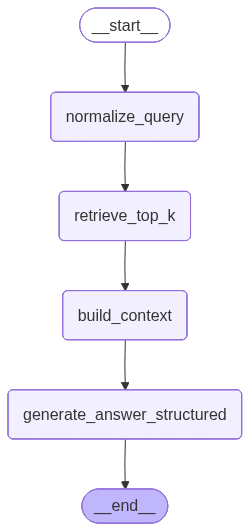

In [5]:
from IPython.display import Image

app = build_rag_graph(runtime.config, runtime)
compiled_graph = app.get_graph()

print("LangGraph compilato (baseline naive).")

mermaid = None
if hasattr(compiled_graph, "draw_mermaid"):
    try:
        mermaid = compiled_graph.draw_mermaid()
    except Exception as exc:
        print(f"Impossibile generare Mermaid DSL: {exc}")

if mermaid:
    # print("\nMermaid DSL (fallback testuale):")
    # print(mermaid)
    display(Markdown("```mermaid\n" + mermaid + "\n```"))

    if hasattr(compiled_graph, "draw_mermaid_png"):
        try:
            png_bytes = compiled_graph.draw_mermaid_png()
            if png_bytes:
                display(Image(data=png_bytes))
        except Exception as exc:
            print(f"PNG Mermaid non disponibile: {exc}")
else:
    print("Mermaid non disponibile in questa versione/ambiente.")


## 6) Debug run su domanda singola

Questa cella esegue una domanda end-to-end e mostra:
- trace nodi
- preview retrieval
- summary contesto
- risposta strutturata
- provenance/citazioni


In [6]:
DEBUG_QUESTION = "Quali obblighi procedurali sono previsti per la presentazione di una domanda?"

debug_run = run_rag_question(runtime.config, DEBUG_QUESTION, resources=runtime)
state = debug_run["state"]

print("Question:", debug_run["question"])
print("Trace steps:", [x.get("node") for x in state.get("trace") or []])
print("Retrieved count:", len(state.get("retrieved") or []))

print("\nRetrieved preview")
display(pd.DataFrame(debug_run["retrieved_preview"]))

print("\nFilters used")
display(debug_run["filters_summary"])

print("\nContext summary")
display(debug_run["context_summary"])

print("\nAnswer summary")
display(debug_run["answer_summary"])

print("\nProvenance rows")
display(pd.DataFrame(debug_run["provenance_rows"]))


Question: Quali obblighi procedurali sono previsti per la presentazione di una domanda?
Trace steps: ['normalize_query', 'retrieve_top_k', 'build_context', 'generate_answer_structured']
Retrieved count: 8

Retrieved preview


,rank,chunk_id,law_id,article_id,law_status,law_date,score,source_passage_ids,source_chunk_ids,excerpt
0,1,vda:lr:1994-08-19:51#art:2#rc:1030000-1030000#...,vda:lr:1994-08-19:51,vda:lr:1994-08-19:51#art:2,past,1994-08-19,0.733822,[vda:lr:1994-08-19:51#art:2#p:c3],[vda:lr:1994-08-19:51#art:2#p:c3#chunk:0],3. Il termine di scadenza per la presentazione...
1,2,vda:lr:2010-06-15:17#art:15#rc:0-1010000#u:0#s:0,vda:lr:2010-06-15:17,vda:lr:2010-06-15:17#art:15,past,2010-06-15,0.722250,"[vda:lr:2010-06-15:17#art:15#p:intro, vda:lr:2...","[vda:lr:2010-06-15:17#art:15#p:intro#chunk:0, ...",(Presentazione della domanda) 1. La domanda di...
2,3,vda:lr:1985-08-08:68#art:9#rc:0-0#u:0#s:0,vda:lr:1985-08-08:68,vda:lr:1985-08-08:68#art:9,current,1985-08-08,0.718164,[vda:lr:1985-08-08:68#art:9#p:intro],[vda:lr:1985-08-08:68#art:9#p:intro#chunk:0],In sede di prima applicazione della presente l...
3,4,vda:lr:2017-07-31:11#art:6#rc:1020002-1020002#...,vda:lr:2017-07-31:11,vda:lr:2017-07-31:11#art:6,current,2017-07-31,0.717510,[vda:lr:2017-07-31:11#art:6#p:c2.lit_b],[vda:lr:2017-07-31:11#art:6#p:c2.lit_b#chunk:0],b) presentare domanda per l'inserimento nelle ...
4,5,vda:lr:1996-06-20:12#art:44undecies#rc:1020000...,vda:lr:1996-06-20:12,vda:lr:1996-06-20:12#art:44undecies,past,1996-06-20,0.712844,[vda:lr:1996-06-20:12#art:44undecies#p:c2],[vda:lr:1996-06-20:12#art:44undecies#p:c2#chun...,"2. I soggetti di cui all'articolo 28, comma 1,..."
5,6,vda:lr:1995-10-23:45#art:58#rc:0-1020000#u:0#s:0,vda:lr:1995-10-23:45,vda:lr:1995-10-23:45#art:58,current,1995-10-23,0.712036,"[vda:lr:1995-10-23:45#art:58#p:intro, vda:lr:1...","[vda:lr:1995-10-23:45#art:58#p:intro#chunk:0, ...",CONTROLLO DELLA SPESA (Dimissioni volontarie) ...
6,7,vda:lr:2018-03-29:6#art:6#rc:1080000-1080000#u...,vda:lr:2018-03-29:6,vda:lr:2018-03-29:6#art:6,current,2018-03-29,0.711964,[vda:lr:2018-03-29:6#art:6#p:c8],[vda:lr:2018-03-29:6#art:6#p:c8#chunk:0],8. Non sono ammissibili richieste relative a i...
7,8,vda:lr:2006-01-03:1#art:9#rc:1050000-1050000#u...,vda:lr:2006-01-03:1,vda:lr:2006-01-03:1#art:9,current,2006-01-03,0.711829,[vda:lr:2006-01-03:1#art:9#p:c5],[vda:lr:2006-01-03:1#art:9#p:c5#chunk:0],"5. Nei casi di cui al comma 1, il Comune decid..."



Filters used


{'view_filter': 'none',
 'law_status_filter': None,
 'relation_types_filter': [],
 'year_from': None,
 'year_to': None,
 'metadata_mode': 'naive',
 'metadata_heuristics': [],
 'raw_filter_present': False}


Context summary


{'included_chunk_ids': ['vda:lr:1994-08-19:51#art:2#rc:1030000-1030000#u:4#s:0',
  'vda:lr:2010-06-15:17#art:15#rc:0-1010000#u:0#s:0',
  'vda:lr:1985-08-08:68#art:9#rc:0-0#u:0#s:0',
  'vda:lr:2017-07-31:11#art:6#rc:1020002-1020002#u:4#s:0',
  'vda:lr:1996-06-20:12#art:44undecies#rc:1020000-1020000#u:1#s:0',
  'vda:lr:1995-10-23:45#art:58#rc:0-1020000#u:0#s:0',
  'vda:lr:2018-03-29:6#art:6#rc:1080000-1080000#u:9#s:0',
  'vda:lr:2006-01-03:1#art:9#rc:1050000-1050000#u:5#s:0'],
 'included_count': 8,
 'total_candidates': 8,
 'truncated_chunks': 0,
 'total_chars': 4091}


Answer summary


{'answer': 'Per presentare correttamente una domanda occorre rispettare i seguenti obblighi procedurali:\\n\\n1. **Termine di presentazione**: la domanda deve essere presentata entro il 30 novembre di ogni anno; le domande pervenute successivamente non sono ammesse【vda:lr:1994-08-19:51#art:2】.\\n\\n2. **Destinatario**: la domanda va indirizzata alla struttura competente\u200b【vda:lr:2010-06-15:17#art:15】.\\n\\n3. **Contenuto richiesto**: è necessario indicare le misure preventive che si intendono attuare e le relative modalità di realizzazione\u200b【vda:lr:2010-06-15:17#art:15】.\\n\\n4. **Documentazione allegata**: la domanda deve essere corredata, ove previsto, di copie in forma autentica dell’attestazione di qualificazione (es. SOA) e di una dichiarazione sostitutiva in cui il richiedente attesta di non trovarsi in nessuna delle cause di esclusione dalle gare di appalto\u200b【vda:lr:1996-06-20:12#art:44undecies】.\\n\\n5. **Forma scritta**: le domande (es. dimissioni volontarie) devon


Provenance rows


,chunk_id,law_id,article_id,source_chunk_ids,source_passage_ids,score,cited
0,vda:lr:1994-08-19:51#art:2#rc:1030000-1030000#...,vda:lr:1994-08-19:51,vda:lr:1994-08-19:51#art:2,[vda:lr:1994-08-19:51#art:2#p:c3#chunk:0],[vda:lr:1994-08-19:51#art:2#p:c3],0.733822,False
1,vda:lr:2010-06-15:17#art:15#rc:0-1010000#u:0#s:0,vda:lr:2010-06-15:17,vda:lr:2010-06-15:17#art:15,"[vda:lr:2010-06-15:17#art:15#p:intro#chunk:0, ...","[vda:lr:2010-06-15:17#art:15#p:intro, vda:lr:2...",0.722250,False
2,vda:lr:1985-08-08:68#art:9#rc:0-0#u:0#s:0,vda:lr:1985-08-08:68,vda:lr:1985-08-08:68#art:9,[vda:lr:1985-08-08:68#art:9#p:intro#chunk:0],[vda:lr:1985-08-08:68#art:9#p:intro],0.718164,False
3,vda:lr:2017-07-31:11#art:6#rc:1020002-1020002#...,vda:lr:2017-07-31:11,vda:lr:2017-07-31:11#art:6,[vda:lr:2017-07-31:11#art:6#p:c2.lit_b#chunk:0],[vda:lr:2017-07-31:11#art:6#p:c2.lit_b],0.717510,False
4,vda:lr:1996-06-20:12#art:44undecies#rc:1020000...,vda:lr:1996-06-20:12,vda:lr:1996-06-20:12#art:44undecies,[vda:lr:1996-06-20:12#art:44undecies#p:c2#chun...,[vda:lr:1996-06-20:12#art:44undecies#p:c2],0.712844,False
5,vda:lr:1995-10-23:45#art:58#rc:0-1020000#u:0#s:0,vda:lr:1995-10-23:45,vda:lr:1995-10-23:45#art:58,"[vda:lr:1995-10-23:45#art:58#p:intro#chunk:0, ...","[vda:lr:1995-10-23:45#art:58#p:intro, vda:lr:1...",0.712036,False
6,vda:lr:2018-03-29:6#art:6#rc:1080000-1080000#u...,vda:lr:2018-03-29:6,vda:lr:2018-03-29:6#art:6,[vda:lr:2018-03-29:6#art:6#p:c8#chunk:0],[vda:lr:2018-03-29:6#art:6#p:c8],0.711964,False
7,vda:lr:2006-01-03:1#art:9#rc:1050000-1050000#u...,vda:lr:2006-01-03:1,vda:lr:2006-01-03:1#art:9,[vda:lr:2006-01-03:1#art:9#p:c5#chunk:0],[vda:lr:2006-01-03:1#art:9#p:c5],0.711829,False


## 7) Batch qualitativo breve (5 domande)

Batch veloce per controllare robustezza qualitativa della baseline
su casi di natura diversa (procedurale, article-specific, temporale, ambiguo, cross-law).


In [7]:
example_questions = [
    {
        "id": "q1_straightforward",
        "question": "Qual e la procedura prevista per presentare una domanda di contributo?",
        "category": "straightforward",
    },
    {
        "id": "q2_article_specific",
        "question": "Che cosa prevede l'articolo 3 della L.R. 22 dicembre 2017, n. 21?",
        "category": "article_specific",
    },
    {
        "id": "q3_temporal",
        "question": "Quando e stata in vigore la L.R. 20 novembre 2006, n. 26 e qual e il suo stato?",
        "category": "temporal",
    },
    {
        "id": "q4_ambiguous",
        "question": "Come funziona la norma sulle autorizzazioni?",
        "category": "ambiguous",
    },
    {
        "id": "q5_cross_law",
        "question": "Quali leggi hanno modificato la L.R. 11 febbraio 2020, n. 1?",
        "category": "cross_law",
    },
]

batch_runs = []
for item in example_questions:
    result = run_rag_question(runtime.config, item["question"], resources=runtime)
    batch_runs.append(
        {
            "id": item["id"],
            "category": item["category"],
            "question": item["question"],
            "result": result,
        }
    )

summary_rows = []
for run in batch_runs:
    answer = run["result"]["answer_summary"]
    summary_rows.append(
        {
            "id": run["id"],
            "category": run["category"],
            "retrieved": len(run["result"]["retrieved_preview"]),
            "citations": len(answer.get("citations") or []),
            "needs_more_context": bool(answer.get("needs_more_context")),
            "answer_preview": (answer.get("answer") or "")[:180],
        }
    )

display(pd.DataFrame(summary_rows))


,id,category,retrieved,citations,needs_more_context,answer_preview
0,q1_straightforward,straightforward,8,0,False,Per accedere ai contributi è necessario presen...
1,q2_article_specific,article_specific,8,0,True,Nel contesto fornito non è presente il testo d...
2,q3_temporal,temporal,8,0,True,Con il contesto fornito non è possibile determ...
3,q4_ambiguous,ambiguous,8,0,False,"Secondo la normativa regionale, la procedura p..."
4,q5_cross_law,cross_law,8,0,True,Con le informazioni fornite non è possibile id...


## 8) Caricamento benchmark condiviso (`data/evaluation/*`)

Usiamo gli stessi CSV del notebook `evaluation/02`, con subset rapido configurabile.
L'allineamento no-hint/MCQ viene validato in fail-fast.


In [8]:
mcq_rows = load_valid_rows(EVAL_MCQ_CSV)
no_hint_rows = load_valid_rows(EVAL_NO_HINT_CSV)

max_available = min(len(mcq_rows), len(no_hint_rows))
if BENCHMARK_START_POS < 0 or BENCHMARK_START_POS >= max_available:
    raise IndexError(f"BENCHMARK_START_POS fuori range: {BENCHMARK_START_POS}")

end_pos = min(BENCHMARK_START_POS + BENCHMARK_LIMIT, max_available)
EVAL_POSITIONS = list(range(BENCHMARK_START_POS, end_pos))
if not EVAL_POSITIONS:
    raise RuntimeError("Nessuna posizione da valutare")

for pos in EVAL_POSITIONS:
    _ = align_record(pos, no_hint_rows, mcq_rows)

display(
    {
        "mcq_valid_rows": len(mcq_rows),
        "no_hint_valid_rows": len(no_hint_rows),
        "eval_start": EVAL_POSITIONS[0],
        "eval_end": EVAL_POSITIONS[-1],
        "eval_n": len(EVAL_POSITIONS),
    }
)


{'mcq_valid_rows': 100,
 'no_hint_valid_rows': 100,
 'eval_start': 0,
 'eval_end': 19,
 'eval_n': 20}

## 9) Setup chiamate structured per benchmark

Per il mini benchmark usiamo endpoint chat OpenAI-compatible con output structured JSON.
Le utility condivise (`post_structured_chat`) gestiscono payload e parsing base.


In [9]:
UTOPIA_API_KEY = os.getenv("UTOPIA_API_KEY", "")
if not UTOPIA_API_KEY:
    raise RuntimeError("UTOPIA_API_KEY mancante: necessario per benchmark structured")

BASE_URL_RAW = os.getenv("UTOPIA_BASE_URL", "https://utopia.hpc4ai.unito.it")
UTOPIA_OLLAMA_CHAT_URL = os.getenv("UTOPIA_OLLAMA_CHAT_URL")
API_URL = resolve_ollama_chat_url(BASE_URL_RAW, explicit_url=UTOPIA_OLLAMA_CHAT_URL)

CHAT_MODEL = os.getenv("UTOPIA_CHAT_MODEL", config.llm_model)
JUDGE_MODEL = os.getenv("UTOPIA_JUDGE_MODEL", CHAT_MODEL)
TIMEOUT_SEC = 120

HEADERS = {
    "Authorization": f"Bearer {UTOPIA_API_KEY}",
    "Content-Type": "application/json",
}

print(json.dumps({
    "base_url_raw": BASE_URL_RAW,
    "utopia_ollama_chat_url_override": UTOPIA_OLLAMA_CHAT_URL,
    "api_url": API_URL,
    "chat_model": CHAT_MODEL,
    "judge_model": JUDGE_MODEL,
    "timeout_sec": TIMEOUT_SEC,
    "fail_fast_scoring_smoke": FAIL_FAST_SCORING_SMOKE,
}, ensure_ascii=False, indent=2))


{
  "base_url_raw": "https://utopia.hpc4ai.unito.it/api",
  "utopia_ollama_chat_url_override": null,
  "api_url": "https://utopia.hpc4ai.unito.it/ollama/api/chat",
  "chat_model": "SLURM.gpt-oss:120b",
  "judge_model": "SLURM.gpt-oss:120b",
  "timeout_sec": 120,
  "fail_fast_scoring_smoke": true
}


## 9.1) Smoke test canale scoring (fail-fast)

Prima dei loop lunghi facciamo una chiamata structured di prova verso l'endpoint benchmark.

- se `RUN_MINI_BENCHMARK=False`, la smoke viene saltata
- se fallisce e `FAIL_FAST_SCORING_SMOKE=True`, fermiamo subito il notebook con errore esplicativo
- se passa, proseguiamo con sezioni 10/11


In [10]:
SCORING_SMOKE: dict[str, Any] = {
    "ok": None,
    "error": None,
    "sample_qid": None,
    "sample_pos": None,
}

if RUN_MINI_BENCHMARK:
    sample_pos = EVAL_POSITIONS[0]
    sample_record = align_record(sample_pos, no_hint_rows, mcq_rows)
    sample_prompt = (
        build_mcq_prompt(sample_record)
        + "\n\nContesto RAG (smoke test tecnico):\nContesto di test per verifica endpoint."
    )
    SCORING_SMOKE["sample_qid"] = sample_record["qid"]
    SCORING_SMOKE["sample_pos"] = sample_pos
    try:
        smoke_out = post_structured_chat(
            api_url=API_URL,
            headers=HEADERS,
            payload_schema=schema_to_json_dict(McqAnswer),
            prompt=sample_prompt,
            model=CHAT_MODEL,
            timeout=TIMEOUT_SEC,
        )
        smoke_obj = validate_mcq_output(smoke_out["structured"])
        SCORING_SMOKE["ok"] = True
        print(f"Smoke test OK: qid={sample_record['qid']} label={smoke_obj.answer_label}")
    except Exception as exc:
        SCORING_SMOKE["ok"] = False
        SCORING_SMOKE["error"] = str(exc)
        print(f"Smoke test FAILED su API_URL={API_URL} -> {exc}")
        if FAIL_FAST_SCORING_SMOKE:
            raise RuntimeError(
                "Smoke test scoring fallito. Correggi endpoint/credenziali prima del benchmark lungo. "
                f"Dettaglio: {exc}"
            )
else:
    print("RUN_MINI_BENCHMARK=False: smoke test scoring saltato")

display({
    "api_url": API_URL,
    "smoke_ok": SCORING_SMOKE["ok"],
    "smoke_error": SCORING_SMOKE["error"],
    "sample_qid": SCORING_SMOKE["sample_qid"],
    "sample_pos": SCORING_SMOKE["sample_pos"],
})


Smoke test OK: qid=1 label=D


{'api_url': 'https://utopia.hpc4ai.unito.it/ollama/api/chat',
 'smoke_ok': True,
 'smoke_error': None,
 'sample_qid': '1',
 'sample_pos': 0}

## 10) Mini benchmark MCQ (retrieval/context + 1 chiamata LLM strutturata)

Flusso per ogni domanda:
1. retrieval/context con query stem (`question_no_hint`)
2. singola chiamata MCQ structured (A-F) usando domanda con opzioni + contesto RAG
3. scoring deterministico rispetto alla label gold


In [11]:
mcq_results: list[dict[str, Any]] = []

if RUN_MINI_BENCHMARK:
    for idx, pos in enumerate(EVAL_POSITIONS, start=1):
        t0 = perf_counter()
        record = align_record(pos, no_hint_rows, mcq_rows)

        predicted_label = ""
        raw_structured = None
        error = None
        score = None
        status = "ok"

        t_retrieval_context_s = None
        t_task_llm_s = None
        t_total_s = None

        retrieval_result = None
        context_text = ""

        # Stage A - retrieval/context only
        try:
            tr0 = perf_counter()
            retrieval_result = run_rag_retrieval_context(
                runtime.config,
                record["question_no_hint"],
                resources=runtime,
            )
            t_retrieval_context_s = perf_counter() - tr0
            context_text = str((retrieval_result.get("state") or {}).get("context") or "")
        except Exception as exc:
            status = "retrieval_error"
            error = f"retrieval_error: {type(exc).__name__}: {exc}".splitlines()[0]

        # Stage B - single MCQ structured call
        if error is None:
            try:
                ts0 = perf_counter()
                prompt = (
                    build_mcq_prompt(record)
                    + "\n\nContesto RAG (usa questo contesto come base informativa):\n"
                    + context_text
                )
                call_out = post_structured_chat(
                    api_url=API_URL,
                    headers=HEADERS,
                    payload_schema=schema_to_json_dict(McqAnswer),
                    prompt=prompt,
                    model=CHAT_MODEL,
                    timeout=TIMEOUT_SEC,
                )
                raw_structured = call_out["structured"]
                mcq_obj = validate_mcq_output(raw_structured)
                predicted_label = mcq_obj.answer_label
                score = 1 if predicted_label == record["ground_truth_label_mcq"] else 0
                t_task_llm_s = perf_counter() - ts0
            except Exception as exc:
                status = "mcq_classification_error"
                error = f"mcq_structured_error: {type(exc).__name__}: {exc}".splitlines()[0]

        t_total_s = perf_counter() - t0

        item = {
            "qid": record["qid"],
            "level": record["level"],
            "pos": pos,
            "ground_truth_label": record["ground_truth_label_mcq"],
            "predicted_label": predicted_label,
            "score": score,
            "is_correct": (score == 1) if score in (0, 1) else None,
            "status": status,
            "error": error,
            "raw_response": raw_structured,
            "retrieval_query_mode": "question_no_hint",
            "retrieved_count": len((retrieval_result or {}).get("retrieved_preview") or []),
            "scoring_stage": "mcq_classification",
            "api_url_used": API_URL,
            "smoke_ok": SCORING_SMOKE.get("ok"),
            "llm_calls_expected": 1,
            "t_retrieval_context_s": t_retrieval_context_s,
            "t_task_llm_s": t_task_llm_s,
            "t_judge_s": None,
            "t_total_s": t_total_s,
        }
        mcq_results.append(item)

        status_txt = f"score={score}" if score in (0, 1) else "score=NA"
        print(f"[RAG-MCQ {idx}/{len(EVAL_POSITIONS)}] qid={item['qid']} level={item['level']} {status_txt}")
else:
    print("RUN_MINI_BENCHMARK=False: sezione MCQ saltata")


[RAG-MCQ 1/20] qid=1 level=L1 score=1
[RAG-MCQ 2/20] qid=2 level=L2 score=1
[RAG-MCQ 3/20] qid=3 level=L3 score=1
[RAG-MCQ 4/20] qid=4 level=L4 score=1
[RAG-MCQ 5/20] qid=5 level=L1 score=1
[RAG-MCQ 6/20] qid=6 level=L2 score=1
[RAG-MCQ 7/20] qid=7 level=L3 score=0
[RAG-MCQ 8/20] qid=8 level=L4 score=1
[RAG-MCQ 9/20] qid=9 level=L1 score=1
[RAG-MCQ 10/20] qid=10 level=L2 score=1
[RAG-MCQ 11/20] qid=11 level=L3 score=1
[RAG-MCQ 12/20] qid=12 level=L4 score=1
[RAG-MCQ 13/20] qid=13 level=L1 score=1
[RAG-MCQ 14/20] qid=14 level=L2 score=0
[RAG-MCQ 15/20] qid=15 level=L3 score=1
[RAG-MCQ 16/20] qid=16 level=L4 score=0
[RAG-MCQ 17/20] qid=17 level=L1 score=0
[RAG-MCQ 18/20] qid=18 level=L2 score=1
[RAG-MCQ 19/20] qid=19 level=L3 score=1
[RAG-MCQ 20/20] qid=20 level=L4 score=1


## 11) Mini benchmark no-hint + judge (policy risposte vuote)

Flusso per ogni domanda:
1. retrieval/context con query stem (`question_no_hint`)
2. answer generation no-hint strutturata (con retry)
3. judge solo se risposta valida

Policy: se la risposta resta vuota/invalida dopo retry, la riga e' classificata come errore tecnico non judged.


In [12]:
no_hint_results: list[dict[str, Any]] = []

if RUN_MINI_BENCHMARK:
    for idx, pos in enumerate(EVAL_POSITIONS, start=1):
        t0 = perf_counter()
        record = align_record(pos, no_hint_rows, mcq_rows)

        rag_answer_text = ""
        raw_step1 = None
        judge_result = None
        raw_judge = None
        final_binary_score = None
        error = None
        status = "ok"

        t_retrieval_context_s = None
        t_task_llm_s = None
        t_judge_s = None
        t_total_s = None

        retrieval_result = None
        context_text = ""

        # Stage A - retrieval/context
        try:
            tr0 = perf_counter()
            retrieval_result = run_rag_retrieval_context(
                runtime.config,
                record["question_no_hint"],
                resources=runtime,
            )
            t_retrieval_context_s = perf_counter() - tr0
            context_text = str((retrieval_result.get("state") or {}).get("context") or "")
        except Exception as exc:
            status = "retrieval_error"
            error = f"retrieval_error: {type(exc).__name__}: {exc}".splitlines()[0]

        # Stage B - no-hint answer generation (retry)
        answer_attempts = 0
        if error is None:
            ts0 = perf_counter()
            last_exc = None
            for attempt in range(NO_HINT_MAX_RETRIES + 1):
                answer_attempts = attempt + 1
                try:
                    step1_prompt = (
                        build_no_hint_prompt(record)
                        + "\n\nContesto RAG (usa questo contesto come base informativa):\n"
                        + context_text
                    )
                    step1_out = post_structured_chat(
                        api_url=API_URL,
                        headers=HEADERS,
                        payload_schema=schema_to_json_dict(NoHintAnswer),
                        prompt=step1_prompt,
                        model=CHAT_MODEL,
                        timeout=TIMEOUT_SEC,
                    )
                    raw_step1 = step1_out["structured"]
                    step1_obj = validate_no_hint_output(raw_step1)
                    candidate_answer = str(step1_obj.answer_text or "").strip()
                    rag_answer_text = candidate_answer
                    if is_effective_answer(candidate_answer, min_chars=MIN_ANSWER_CHARS):
                        last_exc = None
                        break
                    last_exc = RuntimeError("answer_empty_or_invalid")
                except Exception as exc:
                    last_exc = exc
                    continue

            t_task_llm_s = perf_counter() - ts0

            if not is_effective_answer(rag_answer_text, min_chars=MIN_ANSWER_CHARS):
                status = "answer_empty_or_invalid"
                error = (
                    f"no_hint_generation_error: {type(last_exc).__name__}: {last_exc}"
                    if last_exc is not None
                    else "no_hint_generation_error: answer_empty_or_invalid"
                ).splitlines()[0]

        # Stage C - judge only if answer is valid
        if error is None:
            try:
                tj0 = perf_counter()
                judge_out = post_structured_chat(
                    api_url=API_URL,
                    headers=HEADERS,
                    payload_schema=schema_to_json_dict(JudgeResult),
                    prompt=build_judge_prompt(record, rag_answer_text),
                    model=JUDGE_MODEL,
                    timeout=TIMEOUT_SEC,
                )
                raw_judge = judge_out["structured"]
                judge_obj = validate_judge_output(raw_judge)
                judge_result = judge_obj.model_dump()
                final_binary_score = int(judge_obj.score)
                t_judge_s = perf_counter() - tj0
            except Exception as exc:
                status = "judge_error"
                error = f"judge_structured_error: {type(exc).__name__}: {exc}".splitlines()[0]
        elif status == "answer_empty_or_invalid" and not SKIP_JUDGE_IF_EMPTY:
            try:
                tj0 = perf_counter()
                judge_out = post_structured_chat(
                    api_url=API_URL,
                    headers=HEADERS,
                    payload_schema=schema_to_json_dict(JudgeResult),
                    prompt=build_judge_prompt(record, rag_answer_text),
                    model=JUDGE_MODEL,
                    timeout=TIMEOUT_SEC,
                )
                raw_judge = judge_out["structured"]
                judge_obj = validate_judge_output(raw_judge)
                judge_result = judge_obj.model_dump()
                final_binary_score = int(judge_obj.score)
                t_judge_s = perf_counter() - tj0
                error = None
                status = "ok"
            except Exception as exc:
                status = "judge_error"
                error = f"judge_structured_error: {type(exc).__name__}: {exc}".splitlines()[0]

        t_total_s = perf_counter() - t0

        item = {
            "qid": record["qid"],
            "level": record["level"],
            "pos": pos,
            "predicted_answer": rag_answer_text,
            "answer_attempts": answer_attempts,
            "judge_context": {
                "question_mcq_full": record["question_mcq_full"],
                "correct_option_label": record["ground_truth_label_mcq"],
                "correct_option_text": record["correct_option_text"],
            },
            "judge_result": judge_result,
            "final_binary_score": final_binary_score,
            "status": status,
            "error": error,
            "raw_step1": raw_step1,
            "raw_judge": raw_judge,
            "retrieval_query_mode": "question_no_hint",
            "retrieved_count": len((retrieval_result or {}).get("retrieved_preview") or []),
            "scoring_stage": "no_hint_then_judge",
            "api_url_used": API_URL,
            "smoke_ok": SCORING_SMOKE.get("ok"),
            "llm_calls_expected": 2,
            "t_retrieval_context_s": t_retrieval_context_s,
            "t_task_llm_s": t_task_llm_s,
            "t_judge_s": t_judge_s,
            "t_total_s": t_total_s,
        }
        no_hint_results.append(item)

        status_txt = f"score={final_binary_score}" if final_binary_score in (0, 1) else "score=NA"
        print(f"[RAG-NO_HINT {idx}/{len(EVAL_POSITIONS)}] qid={item['qid']} level={item['level']} {status_txt}")
else:
    print("RUN_MINI_BENCHMARK=False: sezione no-hint+judge saltata")


[RAG-NO_HINT 1/20] qid=1 level=L1 score=0
[RAG-NO_HINT 2/20] qid=2 level=L2 score=1
[RAG-NO_HINT 3/20] qid=3 level=L3 score=1
[RAG-NO_HINT 4/20] qid=4 level=L4 score=0
[RAG-NO_HINT 5/20] qid=5 level=L1 score=0
[RAG-NO_HINT 6/20] qid=6 level=L2 score=0
[RAG-NO_HINT 7/20] qid=7 level=L3 score=0
[RAG-NO_HINT 8/20] qid=8 level=L4 score=0
[RAG-NO_HINT 9/20] qid=9 level=L1 score=1
[RAG-NO_HINT 10/20] qid=10 level=L2 score=1
[RAG-NO_HINT 11/20] qid=11 level=L3 score=0
[RAG-NO_HINT 12/20] qid=12 level=L4 score=1
[RAG-NO_HINT 13/20] qid=13 level=L1 score=1
[RAG-NO_HINT 14/20] qid=14 level=L2 score=0
[RAG-NO_HINT 15/20] qid=15 level=L3 score=1
[RAG-NO_HINT 16/20] qid=16 level=L4 score=0
[RAG-NO_HINT 17/20] qid=17 level=L1 score=0
[RAG-NO_HINT 18/20] qid=18 level=L2 score=0
[RAG-NO_HINT 19/20] qid=19 level=L3 score=0
[RAG-NO_HINT 20/20] qid=20 level=L4 score=1


## 12) Aggregazioni metriche legacy + estese

Produciamo sia metriche legacy (compatibili con notebook 02) sia metriche estese:
- `coverage = judged/processed`
- `strict_accuracy = correct/processed`
- `empty_answer_count`
- `error_categories`
- `timing_summary` (mean/p50/p90)


In [13]:
mcq_summary = build_dataset_summary("RAG-MCQ", mcq_results, score_key="score")
no_hint_summary = build_dataset_summary(
    "RAG No-Hint + Judge",
    no_hint_results,
    score_key="final_binary_score",
)

mcq_summary_extended = build_extended_summary(
    "RAG-MCQ",
    mcq_results,
    score_key="score",
)
no_hint_summary_extended = build_extended_summary(
    "RAG No-Hint + Judge",
    no_hint_results,
    score_key="final_binary_score",
)

comparison_table = build_comparison_table(mcq_summary, no_hint_summary)

mcq_acc = mcq_summary.get("accuracy")
no_hint_acc = no_hint_summary.get("accuracy")
global_delta = (no_hint_acc - mcq_acc) if (mcq_acc is not None and no_hint_acc is not None) else None

comparison_summary = {
    "global": {
        "mcq_accuracy": mcq_acc,
        "no_hint_accuracy": no_hint_acc,
        "delta_no_hint_minus_mcq": global_delta,
        "mcq_coverage": mcq_summary_extended.get("coverage"),
        "no_hint_coverage": no_hint_summary_extended.get("coverage"),
        "mcq_strict_accuracy": mcq_summary_extended.get("strict_accuracy"),
        "no_hint_strict_accuracy": no_hint_summary_extended.get("strict_accuracy"),
    },
    "by_level": comparison_table["level_rows"],
}

def _timing_rows(dataset_name: str, summary: dict[str, Any]) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    timing = dict(summary.get("timing_summary") or {})
    for stage, stats in timing.items():
        if not isinstance(stats, dict):
            continue
        rows.append(
            {
                "dataset": dataset_name,
                "stage": stage,
                "count": stats.get("count"),
                "mean": stats.get("mean"),
                "p50": stats.get("p50"),
                "p90": stats.get("p90"),
                "min": stats.get("min"),
                "max": stats.get("max"),
            }
        )
    return rows

timing_diagnostics_rows = [
    *_timing_rows("RAG-MCQ", mcq_summary_extended),
    *_timing_rows("RAG No-Hint + Judge", no_hint_summary_extended),
]
timing_diagnostics_df = pd.DataFrame(timing_diagnostics_rows)

print("=== GLOBAL SUMMARY ===")
print(json.dumps({
    "mcq": {
        "processed": mcq_summary["processed"],
        "judged": mcq_summary["judged"],
        "correct": mcq_summary["score_sum"],
        "accuracy": mcq_summary["accuracy"],
        "errors": mcq_summary["errors"],
        "coverage": mcq_summary_extended["coverage"],
        "strict_accuracy": mcq_summary_extended["strict_accuracy"],
    },
    "no_hint": {
        "processed": no_hint_summary["processed"],
        "judged": no_hint_summary["judged"],
        "correct": no_hint_summary["score_sum"],
        "accuracy": no_hint_summary["accuracy"],
        "errors": no_hint_summary["errors"],
        "coverage": no_hint_summary_extended["coverage"],
        "strict_accuracy": no_hint_summary_extended["strict_accuracy"],
        "empty_answer_count": no_hint_summary_extended["empty_answer_count"],
    },
    "comparison": comparison_summary["global"],
}, ensure_ascii=False, indent=2))


=== GLOBAL SUMMARY ===
{
  "mcq": {
    "processed": 20,
    "judged": 20,
    "correct": 16,
    "accuracy": 0.8,
    "errors": 0,
    "coverage": 1.0,
    "strict_accuracy": 0.8
  },
  "no_hint": {
    "processed": 20,
    "judged": 20,
    "correct": 8,
    "accuracy": 0.4,
    "errors": 0,
    "coverage": 1.0,
    "strict_accuracy": 0.4,
    "empty_answer_count": 0
  },
  "comparison": {
    "mcq_accuracy": 0.8,
    "no_hint_accuracy": 0.4,
    "delta_no_hint_minus_mcq": -0.4,
    "mcq_coverage": 1.0,
    "no_hint_coverage": 1.0,
    "mcq_strict_accuracy": 0.8,
    "no_hint_strict_accuracy": 0.4
  }
}


## 12.1) Debug errori benchmark e categorie

Raggruppiamo gli errori per head e mostriamo le categorie tecniche/semantiche per capire subito dove la pipeline perde affidabilita'.


In [14]:
error_heads_mcq = summarize_error_heads(mcq_results)
error_heads_no_hint = summarize_error_heads(no_hint_results)

display({
    "mcq_judged": mcq_summary.get("judged"),
    "mcq_errors": mcq_summary.get("errors"),
    "no_hint_judged": no_hint_summary.get("judged"),
    "no_hint_errors": no_hint_summary.get("errors"),
    "no_hint_empty_answer_count": no_hint_summary_extended.get("empty_answer_count"),
})

print("MCQ error heads")
display(pd.DataFrame(error_heads_mcq))

print("No-Hint error heads")
display(pd.DataFrame(error_heads_no_hint))

print("MCQ error categories")
display(pd.DataFrame([
    {"category": k, "count": v}
    for k, v in sorted((mcq_summary_extended.get("error_categories") or {}).items())
]))

print("No-Hint error categories")
display(pd.DataFrame([
    {"category": k, "count": v}
    for k, v in sorted((no_hint_summary_extended.get("error_categories") or {}).items())
]))


{'mcq_judged': 20,
 'mcq_errors': 0,
 'no_hint_judged': 20,
 'no_hint_errors': 0,
 'no_hint_empty_answer_count': 0}

MCQ error heads


""


No-Hint error heads


""


MCQ error categories


""


No-Hint error categories


""


## 12.2) Visualizzazioni Matplotlib (accuracy, coverage, strict)

Come nel notebook 02, visualizziamo accuracy globale e per livello.
In aggiunta mostriamo coverage e strict_accuracy per avere una lettura end-to-end piu' corretta.


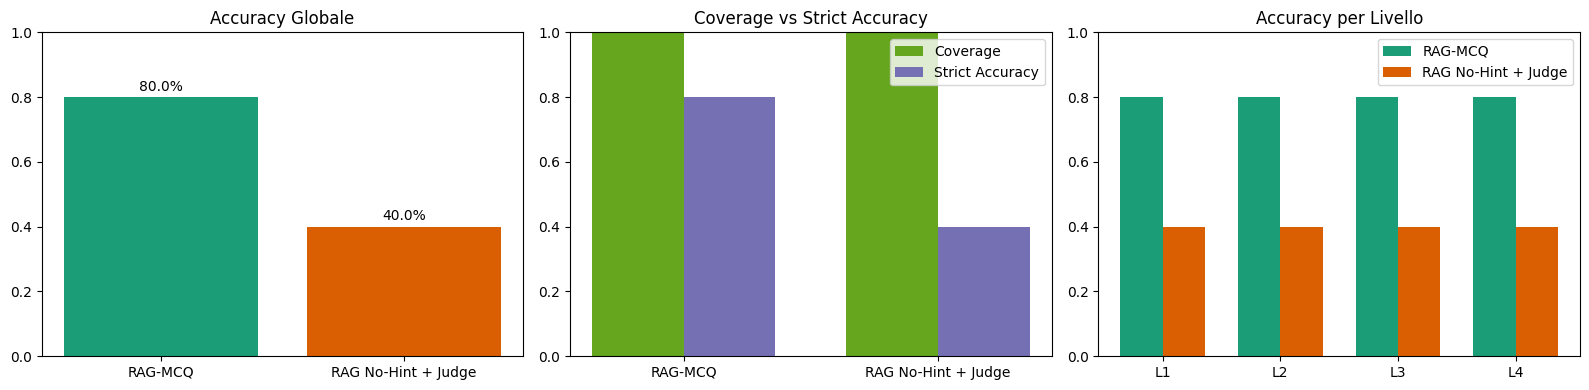

,dataset,processed,judged,correct,accuracy,errors
0,MCQ,20,20,16,0.8,0
1,No-Hint + Judge,20,20,8,0.4,0


,level,mcq_correct,mcq_judged,mcq_accuracy,no_hint_correct,no_hint_judged,no_hint_accuracy,delta_no_hint_minus_mcq
0,L1,4,5,0.8,2,5,0.4,-0.4
1,L2,4,5,0.8,2,5,0.4,-0.4
2,L3,4,5,0.8,2,5,0.4,-0.4
3,L4,4,5,0.8,2,5,0.4,-0.4


In [15]:
comparison_df = pd.DataFrame(comparison_table["global_rows"])
comparison_by_level_df = pd.DataFrame(comparison_table["level_rows"])

all_levels: list[str] = []
if not comparison_by_level_df.empty:
    all_levels = list(comparison_by_level_df["level"].astype(str))

mcq_global_acc = mcq_summary["accuracy"] if mcq_summary["accuracy"] is not None else 0.0
no_hint_global_acc = no_hint_summary["accuracy"] if no_hint_summary["accuracy"] is not None else 0.0
mcq_coverage = mcq_summary_extended["coverage"] if mcq_summary_extended["coverage"] is not None else 0.0
no_hint_coverage = no_hint_summary_extended["coverage"] if no_hint_summary_extended["coverage"] is not None else 0.0
mcq_strict = mcq_summary_extended["strict_accuracy"] if mcq_summary_extended["strict_accuracy"] is not None else 0.0
no_hint_strict = no_hint_summary_extended["strict_accuracy"] if no_hint_summary_extended["strict_accuracy"] is not None else 0.0

if comparison_by_level_df.empty:
    mcq_level_acc = []
    no_hint_level_acc = []
else:
    mcq_level_acc = [
        float(v) if pd.notna(v) else 0.0
        for v in comparison_by_level_df.get("mcq_accuracy", pd.Series(dtype=float)).tolist()
    ]
    no_hint_level_acc = [
        float(v) if pd.notna(v) else 0.0
        for v in comparison_by_level_df.get("no_hint_accuracy", pd.Series(dtype=float)).tolist()
    ]

x = list(range(len(all_levels)))
width = 0.36

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

bars = axes[0].bar(["RAG-MCQ", "RAG No-Hint + Judge"], [mcq_global_acc, no_hint_global_acc], color=["#1b9e77", "#d95f02"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy Globale")
for bar, val in zip(bars, [mcq_global_acc, no_hint_global_acc]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, min(val + 0.02, 0.99), f"{val:.1%}", ha="center")

x2 = [0, 1]
axes[1].bar([x2[0] - width / 2, x2[1] - width / 2], [mcq_coverage, no_hint_coverage], width, label="Coverage", color="#66a61e")
axes[1].bar([x2[0] + width / 2, x2[1] + width / 2], [mcq_strict, no_hint_strict], width, label="Strict Accuracy", color="#7570b3")
axes[1].set_xticks(x2, ["RAG-MCQ", "RAG No-Hint + Judge"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Coverage vs Strict Accuracy")
axes[1].legend()

if all_levels:
    axes[2].bar([i - width / 2 for i in x], mcq_level_acc, width, label="RAG-MCQ", color="#1b9e77")
    axes[2].bar([i + width / 2 for i in x], no_hint_level_acc, width, label="RAG No-Hint + Judge", color="#d95f02")
    axes[2].set_xticks(x, all_levels)
axes[2].set_ylim(0, 1)
axes[2].set_title("Accuracy per Livello")
axes[2].legend()

plt.tight_layout()
plt.show()

display(comparison_df)
display(comparison_by_level_df)


## 12.3) Timing diagnostics per stage

Questa sezione mostra i tempi medi e percentile per stage:
- retrieval/context
- task LLM
- judge (solo no-hint)
- totale

Serve per capire immediatamente dove nasce la latenza.


,dataset,stage,count,mean,p50,p90,min,max
0,RAG-MCQ,t_retrieval_context_s,20,0.270072,0.268586,0.300795,0.231247,0.321257
1,RAG-MCQ,t_task_llm_s,20,3.438517,3.218360,4.418541,2.464755,4.958708
2,RAG-MCQ,t_judge_s,0,NaN,NaN,NaN,NaN,NaN
3,RAG-MCQ,t_total_s,20,3.708791,3.505065,4.700096,2.739575,5.258088
4,RAG No-Hint + Judge,t_retrieval_context_s,20,0.367272,0.289159,0.554745,0.202271,1.183278
5,RAG No-Hint + Judge,t_task_llm_s,20,3.324905,3.237007,4.311250,2.090287,4.542355
6,RAG No-Hint + Judge,t_judge_s,20,2.706549,2.387641,4.135980,1.637225,4.396313
7,RAG No-Hint + Judge,t_total_s,20,6.399290,6.121675,8.589420,4.500102,9.196246


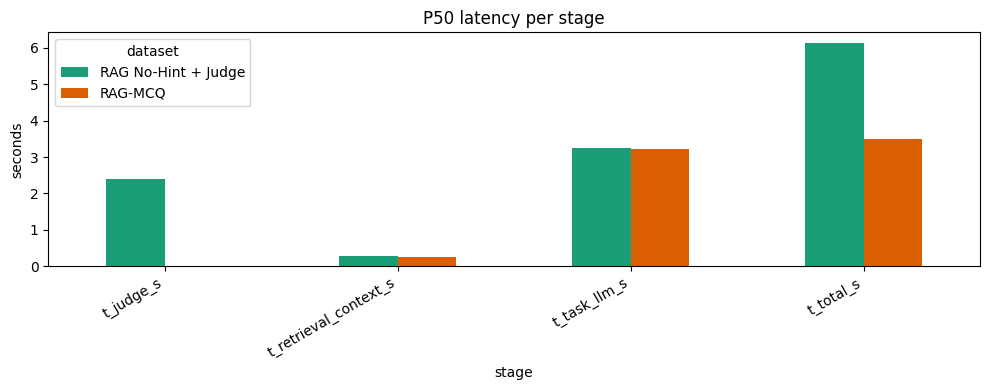

In [16]:
if timing_diagnostics_df.empty:
    print("Nessun timing disponibile")
else:
    display(timing_diagnostics_df)

    # Plot p50 per stage e dataset
    pivot = timing_diagnostics_df.pivot_table(
        index="stage",
        columns="dataset",
        values="p50",
        aggfunc="first",
    ).fillna(0.0)

    ax = pivot.plot(kind="bar", figsize=(10, 4), color=["#1b9e77", "#d95f02"])
    ax.set_title("P50 latency per stage")
    ax.set_ylabel("seconds")
    ax.set_xlabel("stage")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 12.4) Debug retrieval per domanda (1..N)

Utility rapida per ispezionare una singola domanda del benchmark:
- seleziona `qnum_1_based` da 1 a N
- scegli `mode="no_hint"` o `mode="mcq"`
- visualizza trace, chunk retrieved, score e preview contesto


In [17]:
def debug_retrieval_for_question(
    qnum_1_based: int,
    *,
    mode: str = "no_hint",
    preview_chars: int = 320,
) -> dict[str, Any]:
    if qnum_1_based <= 0:
        raise ValueError("qnum_1_based deve essere >= 1")

    pos = qnum_1_based - 1
    record = align_record(pos, no_hint_rows, mcq_rows)
    if mode not in {"no_hint", "mcq"}:
        raise ValueError("mode deve essere 'no_hint' oppure 'mcq'")

    retrieval_query = record["question_no_hint"]
    run = run_rag_retrieval_context(runtime.config, retrieval_query, resources=runtime)
    state = run["state"]
    retrieved = list(state.get("retrieved") or [])

    rows: list[dict[str, Any]] = []
    for rank, doc in enumerate(retrieved, start=1):
        rows.append(
            {
                "rank": rank,
                "score": float(doc.score),
                "chunk_id": doc.chunk_id,
                "law_id": doc.law_id,
                "article_id": doc.article_id,
                "index_views": ", ".join(doc.index_views),
                "law_status": doc.law_status,
                "source_passage_ids": ", ".join(doc.source_passage_ids[:4]),
                "text_preview": (doc.text or "")[:preview_chars],
            }
        )

    print(f"qid={record['qid']} level={record['level']} pos={pos} mode={mode}")
    print("Retrieval query (stem):", retrieval_query[:220])
    print("Trace:", [evt.get("node") for evt in (state.get("trace") or [])])
    print("Retrieved:", len(retrieved))

    df = pd.DataFrame(rows)
    display(df)

    context_preview = str((state.get("context") or ""))[:1000]
    print("\nContext preview:")
    print(context_preview)

    return {
        "record": record,
        "run": run,
        "retrieved_df": df,
    }

# Esempio:
# _dbg = debug_retrieval_for_question(7, mode="no_hint")


## 12.5) Debug scoring per domanda (opzionale)

Questa utility permette di ispezionare prompt e output structured su una singola domanda.

Serve per distinguere rapidamente:
- problemi endpoint/trasporto
- problemi schema structured
- problemi semantici task-specific


In [18]:
def debug_scoring_for_question(
    qnum_1_based: int,
    *,
    mode: str = "mcq",
) -> dict[str, Any]:
    if qnum_1_based <= 0:
        raise ValueError("qnum_1_based deve essere >= 1")
    if mode not in {"mcq", "no_hint_judge"}:
        raise ValueError("mode deve essere 'mcq' o 'no_hint_judge'")

    pos = qnum_1_based - 1
    record = align_record(pos, no_hint_rows, mcq_rows)

    retrieval_run = run_rag_retrieval_context(
        runtime.config,
        record["question_no_hint"],
        resources=runtime,
    )
    context_text = str((retrieval_run.get("state") or {}).get("context") or "")

    if mode == "mcq":
        prompt = build_mcq_prompt(record) + "\n\nContesto RAG:\n" + context_text
        call_out = post_structured_chat(
            api_url=API_URL,
            headers=HEADERS,
            payload_schema=schema_to_json_dict(McqAnswer),
            prompt=prompt,
            model=CHAT_MODEL,
            timeout=TIMEOUT_SEC,
        )
        validated = validate_mcq_output(call_out["structured"]).model_dump()
    else:
        step1_prompt = build_no_hint_prompt(record) + "\n\nContesto RAG:\n" + context_text
        step1_out = post_structured_chat(
            api_url=API_URL,
            headers=HEADERS,
            payload_schema=schema_to_json_dict(NoHintAnswer),
            prompt=step1_prompt,
            model=CHAT_MODEL,
            timeout=TIMEOUT_SEC,
        )
        step1_obj = validate_no_hint_output(step1_out["structured"])
        answer_text = str(step1_obj.answer_text or "").strip()

        judge_out = post_structured_chat(
            api_url=API_URL,
            headers=HEADERS,
            payload_schema=schema_to_json_dict(JudgeResult),
            prompt=build_judge_prompt(record, answer_text),
            model=JUDGE_MODEL,
            timeout=TIMEOUT_SEC,
        )
        call_out = {
            "structured": {
                "no_hint_answer": step1_out["structured"],
                "judge": judge_out["structured"],
            }
        }
        validated = {
            "no_hint_answer": step1_obj.model_dump(),
            "judge": validate_judge_output(judge_out["structured"]).model_dump(),
        }

    out = {
        "qid": record["qid"],
        "mode": mode,
        "api_url": API_URL,
        "context_preview": context_text[:1200],
        "prompt": prompt if mode == "mcq" else step1_prompt,
        "structured": call_out["structured"],
        "validated": validated,
    }

    print(f"qid={record['qid']} mode={mode}")
    print("validated:", json.dumps(validated, ensure_ascii=False, indent=2))
    return out

# Esempio:
# _score_dbg = debug_scoring_for_question(7, mode="mcq")


## 13) Persistenza artifact benchmark

Salviamo risultati e summary in `notebooks/rag_pipeline/artifacts`:
- `rag_naive_mini_benchmark_<timestamp>.json`
- `rag_naive_mini_benchmark_<timestamp>_mcq.csv`
- `rag_naive_mini_benchmark_<timestamp>_no_hint.csv`


In [19]:
artifacts_dir = ROOT / "notebooks" / "rag_pipeline" / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

run_stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
json_path = artifacts_dir / f"rag_naive_mini_benchmark_{run_stamp}.json"
mcq_csv_path = artifacts_dir / f"rag_naive_mini_benchmark_{run_stamp}_mcq.csv"
no_hint_csv_path = artifacts_dir / f"rag_naive_mini_benchmark_{run_stamp}_no_hint.csv"

payload = {
    "run_stamp_utc": run_stamp,
    "config": {
        "top_k": config.top_k,
        "view_filter": config.view_filter,
        "max_context_chunks": config.max_context_chunks,
        "max_context_chars": config.max_context_chars,
        "per_chunk_max_chars": config.per_chunk_max_chars,
        "benchmark_start_pos": BENCHMARK_START_POS,
        "benchmark_limit": BENCHMARK_LIMIT,
        "benchmark_n": len(EVAL_POSITIONS),
        "no_hint_max_retries": NO_HINT_MAX_RETRIES,
        "skip_judge_if_empty": SKIP_JUDGE_IF_EMPTY,
        "min_answer_chars": MIN_ANSWER_CHARS,
    },
    "transport_diagnostics": {
        "base_url_raw": BASE_URL_RAW,
        "api_url": API_URL,
        "smoke_ok": SCORING_SMOKE.get("ok"),
        "smoke_error": SCORING_SMOKE.get("error"),
        "fail_fast_scoring_smoke": FAIL_FAST_SCORING_SMOKE,
    },
    "index_contract": runtime.index_contract.to_dict(),
    "mcq_summary": mcq_summary,
    "no_hint_summary": no_hint_summary,
    "mcq_summary_extended": mcq_summary_extended,
    "no_hint_summary_extended": no_hint_summary_extended,
    "comparison_summary": comparison_summary,
    "error_heads_mcq": error_heads_mcq,
    "error_heads_no_hint": error_heads_no_hint,
    "timing_diagnostics_rows": timing_diagnostics_rows,
    "mcq_results": mcq_results,
    "no_hint_results": no_hint_results,
}

json_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
pd.DataFrame(mcq_results).to_csv(mcq_csv_path, index=False, encoding="utf-8")
pd.DataFrame(no_hint_results).to_csv(no_hint_csv_path, index=False, encoding="utf-8")

print("Artifact JSON:", json_path)
print("Artifact MCQ CSV:", mcq_csv_path)
print("Artifact No-Hint CSV:", no_hint_csv_path)


Artifact JSON: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/rag_pipeline/artifacts/rag_naive_mini_benchmark_20260302_103637.json
Artifact MCQ CSV: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/rag_pipeline/artifacts/rag_naive_mini_benchmark_20260302_103637_mcq.csv
Artifact No-Hint CSV: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/rag_pipeline/artifacts/rag_naive_mini_benchmark_20260302_103637_no_hint.csv


## 14) Estensione verso Advanced RAG

Hook naturali per il notebook successivo:
1. `view_filter` in config (`current`/`historical`)
2. re-retrieval multi-query
3. reranking
4. espansione adiacenza/chunk neighbors
5. graph expansion guidata da `edges/events`

La baseline attuale resta volutamente semplice, testabile e veloce.


In [20]:
advanced_hooks = {
    "view_filter": ["none", "current", "historical"],
    "possible_next_steps": [
        "multi_query_retrieval",
        "metadata_filtering_strategies",
        "reranking",
        "adjacency_expansion",
        "graph_expansion",
    ],
}

display(advanced_hooks)


{'view_filter': ['none', 'current', 'historical'],
 'possible_next_steps': ['multi_query_retrieval',
  'metadata_filtering_strategies',
  'reranking',
  'adjacency_expansion',
  'graph_expansion']}

## 15) Cleanup risorse

Chiudiamo il client Qdrant locale aperto dal runtime.


In [21]:
runtime.close()
print("Runtime chiuso.")


Runtime chiuso.
